In [75]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from feature_eng_exports import data

In [76]:
# sklearn imports
from sklearn.model_selection import KFold, cross_val_score, train_test_split

# Preparing Data

In [77]:
xg_X = data[[
    'model',
    'Fuel',
    'Transmission',
    'KM driven',
    'Engine capacity',
    'Ownership',
    'car_age',
    'ngt_life',
    'ngt_critical',
    'is_luxury_brand',
]].copy()


In [78]:
# Converting Fuel and Transmission to explicitly categorical dtypes :
xg_X['model'] = xg_X['model'].astype('category')
xg_X['Fuel'] = xg_X['Fuel'].astype('category')
xg_X['Transmission'] = xg_X['Transmission'].astype('category')

In [79]:
# Creating Y
xg_Y = pd.Series(np.log1p(data['price']))

# Cross-validation of Initial XGBoost Model

In [80]:
# Initialising initial regressor parameters
bt = xgb.XGBRegressor(
    eta = 0.05,
    min_child_weight = 10,
    subsample = 0.8,
    max_depth = 6,
    enable_categorical=True, 
    random_state = 420
)

In [81]:
# Evaluating cross validation score
xgb_kf = KFold(n_splits=10, shuffle=True, random_state=40)
cross_val_score(bt, xg_X, xg_Y, cv=xgb_kf)

array([0.94178038, 0.96391153, 0.96408542, 0.95870277, 0.96124237,
       0.9580244 , 0.96137639, 0.96057195, 0.95515869, 0.95362662])

# Optuna Tuning of XGBoost Model

In [82]:
X_train, X_test, y_train, y_test = train_test_split(xg_X, xg_Y, test_size=0.2)

In [83]:
def objective(trial):

    param = {
        'eta': trial.suggest_float('eta', 0, 1),
        'lambda': trial.suggest_float('lambda',0,20),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight",2,50),
        "max_depth": trial.suggest_int("max_depth",3,15)

    }
    
    opt_kf = KFold(n_splits=3, shuffle=True, random_state=40)

    optuna_xgb = xgb.XGBRegressor(**param, device = 'cuda')
    opt_score = cross_val_score(optuna_xgb,X_train, y_train, cv=opt_kf).mean()
    
    return opt_score

In [84]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-07-05 03:34:22,870] A new study created in memory with name: no-name-91754000-71a8-461d-9144-38e0ceb85bf2


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-05 03:34:24,922] Trial 0 finished with value: 0.9333464703272574 and parameters: {'eta': 0.6168763441095138, 'lambda': 18.48774824880512, 'alpha': 7.778337372032605e-05, 'subsample': 0.20104203892643727, 'colsample_bytree': 0.5160472926052164, 'min_child_weight': 26, 'max_depth': 10}. Best is trial 0 with value: 0.9333464703272574.
[I 2026-07-05 03:34:26,497] Trial 1 finished with value: 0.9325316321552825 and parameters: {'eta': 0.5671919197424645, 'lambda': 0.28540954517108696, 'alpha': 0.0002655113143400484, 'subsample': 0.2854551598421433, 'colsample_bytree': 0.38979654579277034, 'min_child_weight': 38, 'max_depth': 15}. Best is trial 0 with value: 0.9333464703272574.
[I 2026-07-05 03:34:30,987] Trial 2 finished with value: 0.9401125440440831 and parameters: {'eta': 0.9060890558073008, 'lambda': 18.59406406121267, 'alpha': 5.21123667915363e-07, 'subsample': 0.8572705831642504, 'colsample_bytree': 0.8118004731116248, 'min_child_weight': 11, 'max_depth': 12}. Best is trial

In [85]:
# Storing best parameters :
best_pars = study.best_params
xgb_fin = xgb.XGBRegressor(**best_pars, random_state= 40)
xgb_fin.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6893390146780208
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [86]:
for param, value in best_pars.items():
    print(f"{param} : {value}")

eta : 0.20119200926246103
lambda : 3.7634038729575936
alpha : 0.003583070661110824
subsample : 0.9559619870602681
colsample_bytree : 0.6893390146780208
min_child_weight : 4
max_depth : 7


In [87]:
# Final cross validation scores :
cross_val_score(xgb_fin,X_train, y_train, cv=xgb_kf)

array([0.96506005, 0.95877697, 0.96254219, 0.95707563, 0.96129445,
       0.96156986, 0.96388286, 0.96428634, 0.9590383 , 0.95728073])

In [88]:
# Visualising feature importance :
import optuna.visualization as vis
vis.plot_param_importances(study=study)

In [89]:
vis.plot_optimization_history(study=study)

# Pickling the Model

In [90]:
import pickle

pickle.dump(xgb_fin,open('../streamlit/xgb.pkl', 'wb'))


# SHAP Explainability

In [91]:
import shap

explainer_xgb = shap.TreeExplainer(xgb_fin)
shap_vals = explainer_xgb(X_test)

AttributeError: partially initialized module 'yaml' has no attribute 'error' (most likely due to a circular import)

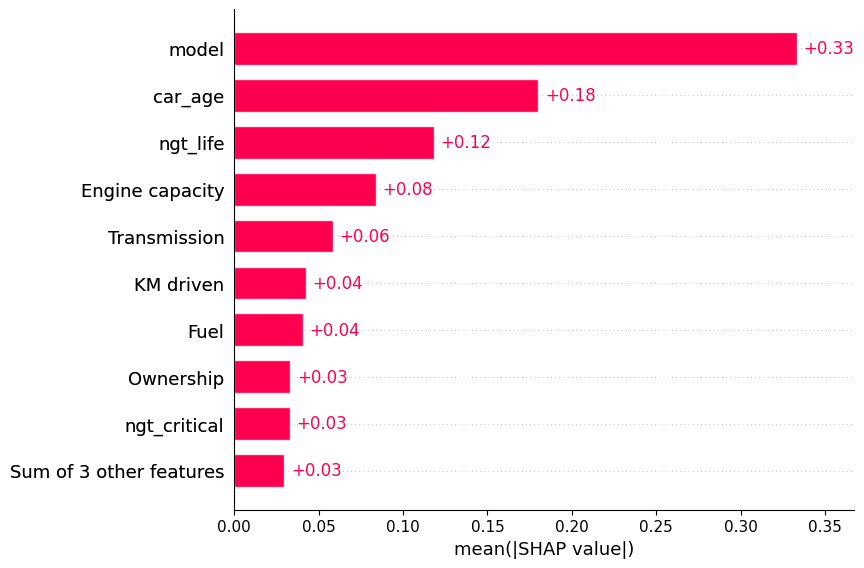

In [ ]:
shap.plots.bar(shap_vals)

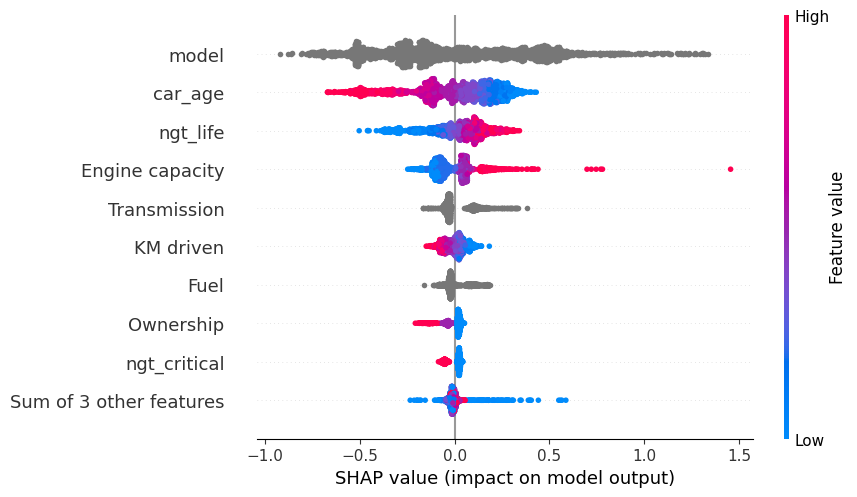

In [ ]:
shap.plots.beeswarm(shap_vals)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score
)

# Predict on log scale
y_pred_log = xgb_fin.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)      

# Metrics on original price scale
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100
medae = median_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MAE   : ₹{mae:,.0f}")
print(f"RMSE  : ₹{rmse:,.0f}")
print(f"MAPE  : {mape:.2f}%")
print(f"MedAE : ₹{medae:,.0f}")
print(f"R²    : {r2:.4f}")

MAE   : ₹69,202
RMSE  : ₹174,764
MAPE  : 11.36%
MedAE : ₹36,873
R²    : 0.9359
